In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "10"
from astropy.io import fits
import pylab
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
import sys
sys.path.append('/home/javva/spt3g_software/scratch/javva/sptslim')
sys.path.append('/home/javva/spt3g_software/build')
from spt3g import core, maps
from spt3g.mapspectra import curved_sky as cs
import glob
import scipy.stats as stats
import pickle
import scipy

##### low-l masks (g3)
- puremask_0p5medwt_30arcmin.npz
- puremask_0p5medwt_60arcmin.npz
- puremask_0p5medwt_120arcmin.npz
- puremask_0p5medwt_180arcmin.npz
- puremask_0p5medwt_240arcmin.npz
- **puremask_0p5medwt_100mJy_30arcmin.npz**
- puremask_0p5medwt_250mJy_30arcmin.npz
- puremask_0p5medwt_250mJy_60arcmin.npz
- puremask_0p5medwt_250mJy_120arcmin.npz
- puremask_0p5medwt_250mJy_180arcmin.npz
- puremask_0p5medwt_250mJy_240arcmin.npz
- puremask_sptpol_60arcmin.npz
-  puremask_sptpol_250mJy_60arcmin.npz

##### mid-l masks (fits)
- puremask8192_0p5medwt_30arcmin.npz
- puremask8192_0p5medwt_60arcmin.npz
- puremask8192_0p5medwt_100mJy_30arcmin.npz
- puremask8192_0p5medwt_250mJy_30arcmin.npz
- puremask8192_0p5medwt_250mJy_60arcmin.npz
- **puremask8192_0p5medwt_250mJy_nodisk_30arcmin.npz**
- puremask8192_0p5medwt_250mJy_nodisk_60arcmin.npz

In [2]:
# show maps available 
dir = '/sptlocal/user/creichardt/bb2020/'

files = glob.glob(dir + '*')
for f in files:
    print(f)

/sptlocal/user/creichardt/bb2020/puremask_0p5medwt_100mJy_30arcmin.npz
/sptlocal/user/creichardt/bb2020/c2mask_0p5medwt_120arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius480_240arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius960_120arcmin.npz
/sptlocal/user/creichardt/bb2020/puremask_0p5medwt_250mJy_180arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius960_480arcmin.npz
/sptlocal/user/creichardt/bb2020/border_lines_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/circletest_puremask_0p5medwt_radius1800_240arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius2400_240arcmin.npz
/sptlocal/user/creichardt/bb2020/distance_xy_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/distance_0p5medwt.npz
/sptlocal/user/creichardt/bb2020/mask_badpixels_180arcmin.npz
/sptlocal/user/creichardt/bb2020/circletest_c2puremask_0p5medwt_radius960_240arcmin.npz
/sptlocal/user/creichardt/bb2020/pur

In [3]:
#### change the mask location here #####
mask_dir = '/sptlocal/user/creichardt/bb2020/'
mask_name = 'puremask8192_0p5medwt_250mJy_nodisk_30arcmin.npz'
########################################
import healpy as hp
mask= np.load(os.path.join(mask_dir, mask_name))['mask']
mask[np.isnan(mask)] = 0


In [4]:
import datetime
import pymaster as nmt
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)
    return cl_decoupled

def run_namaster(dmap,mask,return_nonpureB=False):
    '''                                                                                                                                                                                          
    Note: Only works for apodized mask.                                                                                                                                                          
    '''
    print('1.', datetime.datetime.now())
    b = nmt.NmtBin.from_nside_linear(hp.npix2nside(mask.shape[0]), 10)
    print('2.', datetime.datetime.now())

    if return_nonpureB == False:
        print('3.', datetime.datetime.now())

        f2yp0 = nmt.NmtField(mask, [dmap[1], dmap[2]], purify_e=False, purify_b=True)
        print('4.', datetime.datetime.now())

        w_yp  = nmt.NmtWorkspace()
        w_yp.compute_coupling_matrix(f2yp0, f2yp0, b)
        bpwf = w_yp.get_bandpower_windows()
        bpwf_trim = bpwf[3,:50,3,:1000]
        print('5.', datetime.datetime.now())

        clyp  = compute_master(f2yp0, f2yp0, w_yp)
        print('6#----finished computing namaster----', datetime.datetime.now())

        
        return b.get_effective_ells(), clyp, bpwf

    if return_nonpureB == True:
        f2np0 = nmt.NmtField(mask, [dmap[1], dmap[2]])
        f2yp0 = nmt.NmtField(mask, [dmap[1], dmap[2]], purify_e=False, purify_b=True)

        w_np  = nmt.NmtWorkspace()
        w_np.compute_coupling_matrix(f2np0, f2np0, b)
        w_yp  = nmt.NmtWorkspace()
        w_yp.compute_coupling_matrix(f2yp0, f2yp0, b)

        clnp  = compute_master(f2np0, f2np0, w_np)
        clyp  = compute_master(f2yp0, f2yp0, w_yp)
        print('#----finished computing namaster----')
        return b.get_effective_ells(), clyp, clnp




In [ ]:


map_type = "fits"  # "g3" (low-l, .g3.gz) or "fits" (mid-l, .fits)

if map_type == "g3":
    G3_FILE = "/sptgrid/user/javva/baseline_bb_coadd_match/coadd_fullauto/full/no_signflip_bundle_000.g3.gz"
    FREQ = "90GHz"
    target_frame = None
    for frame in core.G3File(G3_FILE):
        if frame.type == core.G3FrameType.Map and frame['Id'] == FREQ:
            target_frame = frame
            break
    if target_frame is None:
        raise ValueError(f"No Map frame with Id='{FREQ}' found in {G3_FILE}")
    maps.RemoveWeights(target_frame, zero_nans =True)
    dmap = [np.array(target_frame['T']), np.array(target_frame['Q']), -1*np.array(target_frame['U'])]

if map_type == "fits":
    DATA_DIR = "/sptgrid/analysis/spt3g_d1_midell_tqu_healpix"
    COADD_FILE = os.path.join(DATA_DIR, "real_data_maps", "full", "full_095ghz.fits")
    T = hp.read_map(COADD_FILE, field=0, partial=False)
    Q = hp.read_map(COADD_FILE, field=1, partial=False)
    U = hp.read_map(COADD_FILE, field=2, partial=False)
    dmap = [T, Q, -1*U]







: 

In [ ]:
output = run_namaster(dmap, mask)

with open('mask_test_%s_%s.pkl' % (mask_name.split('/')[-1], map_type), 'wb') as f:
    pickle.dump(output, f)

1. 2026-07-16 04:14:24.418042
2. 2026-07-16 04:14:24.419856
3. 2026-07-16 04:14:24.419891


(50, 1000)


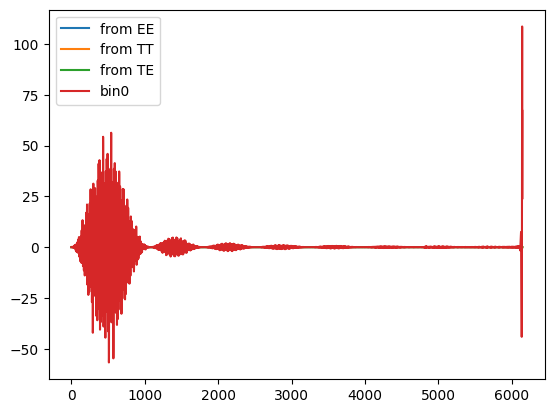

In [ ]:
bpwf_trim = output[2][3,:50,3,:1000]
print(bpwf_trim.shape)
#l,tt,eb
plt.plot(output[2][3,0,0,:]-0.001,label='from EE')
plt.plot(output[2][3,0,1,:],label='from TT')
plt.plot(output[2][3,0,2,:]+.001,label='from TE')
plt.plot(output[2][3,0,3,:],label='bin0')
#plt.plot(output[2][3,1,3,:],label='bin1')
#plt.plot(output[2][3,2,3,:],label='bin2')
#plt.plot(np.arange(0,6144),output[2][3,3,3,:],label='bin3')
#plt.plot(output[2][3,4,3,:],label='bin4')
plt.legend()
#plt.xlim([20,50])

In [ ]:
def cl_to_dl(l,cl):
    return(cl*(l*(l+1.))/(2*np.pi))

ps_dir = {}
for pkl_path in glob.glob('mask_test_*.pkl'):
    tag = pkl_path[len('mask_test_'):-len('.pkl')]
    with open(pkl_path, 'rb') as handle:
        sf = pickle.load(handle)
    ells = sf[0]
    ps_dir[tag] = {}
    ps_dir[tag]['ells'] = ells
    ps_dir[tag]['EE'] = cl_to_dl(ells, sf[1][0]) / core.G3Units.uK**2
    ps_dir[tag]['BB'] = cl_to_dl(ells, sf[1][3]) / core.G3Units.uK**2


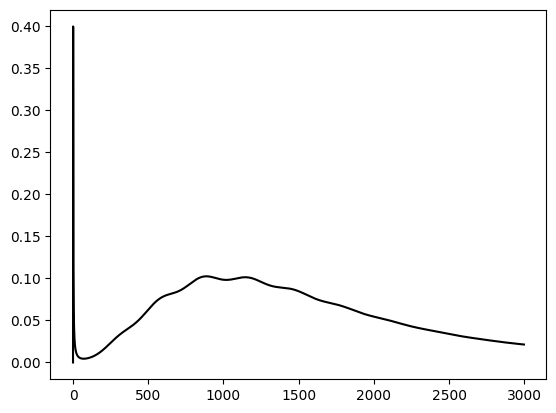

In [ ]:
#get input theory curves
with open('/home/javva/spt3g_software/simulations/scripts/cls_out_bktimes2_bk_alphatimes2_beta_1.6.pkl', 'rb') as handle:
    clsPAaB = pickle.load(handle)
with open('/home/javva/spt3g_software/simulations/scripts/cls_out.pkl', 'rb') as handle:
    cls = pickle.load(handle)
k = 'GD'
k1 = 'cmb'
b = '90GHz'
idx = 2
old_binned = cl_to_dl(np.arange(0,len(clsPAaB[b][k][idx][:5001]),1),(clsPAaB[b][k][idx][:5001]+cls[k1][idx])/core.G3Units.uK**2)
plt.plot(old_binned[:2999],'k-',label = '%s Theory'%b)

Text(0.5, 1.0, 'Testing NaMaster with Different Masks')

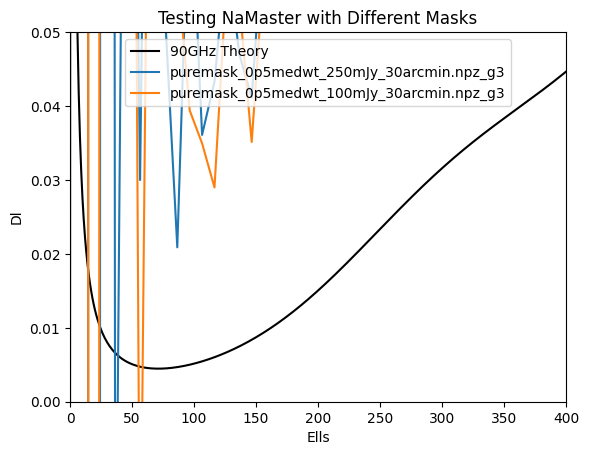

In [ ]:
plt.plot(old_binned[:2999],'k-',label = '%s Theory'%b)
for tag, ps in ps_dir.items():
    plt.plot(ps['ells'], ps['BB'], label=tag)
plt.ylim(0,0.05)
plt.legend()
plt.xlabel('Ells')
plt.xlim(0,400)
plt.ylabel('Dl')
plt.title("Testing NaMaster with Different Masks")

Text(0.5, 1.0, 'Testing NaMaster with Different Masks')

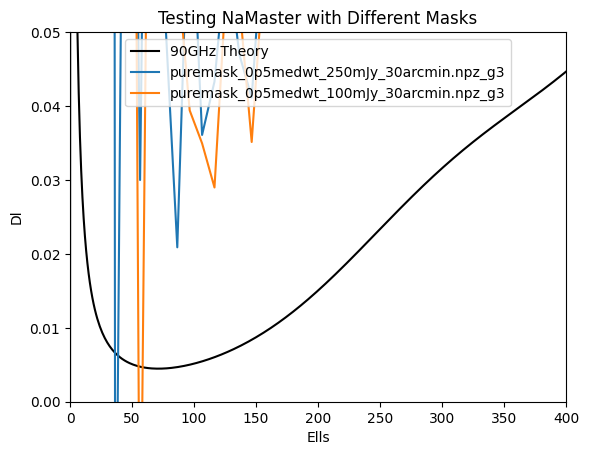

In [ ]:
plt.plot(old_binned[:2999],'k-',label = '%s Theory'%b)
for tag, ps in ps_dir.items():
    plt.plot(ps['ells'][2:], ps['BB'][2:], label=tag)  # skip first 2 bins
plt.ylim(0,0.05)
plt.legend()
plt.xlabel('Ells')
plt.xlim(0,400)
plt.ylabel('Dl')
plt.title("Testing NaMaster with Different Masks")



so instead of using a baseline mask (since i will not use that simulated map anyways) .  i run namaster for severla mask+same map combo, save them in separate pkls  load them and plot them tgt finally